# Treino do Modelo PyTorch (GRU Bidirecional)
Este notebook treina um GRU bidirecional com embeddings aprendidos para classificação multi-classe de texto (Human vs. AI).

In [23]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pickle
import re
import os
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    balanced_accuracy_score, accuracy_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
os.makedirs("plots", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


## 1. Pré-processamento e Construção do Vocabulário

In [24]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return text.split()

def build_vocab(texts, max_words=5000):
    counter = Counter()
    for t in texts:
        counter.update(clean_text(t))
    vocab = {"<pad>": 0, "<unk>": 1}
    for i, (word, _) in enumerate(counter.most_common(max_words - 2), start=2):
        vocab[word] = i
    return vocab

def encode(text, vocab, max_len=100):
    ids = [vocab.get(token, vocab["<unk>"]) for token in clean_text(text)][:max_len]
    if len(ids) < max_len:
        ids += [vocab["<pad>"]] * (max_len - len(ids))
    return ids

## 2. Carregamento dos Dados

In [ ]:
df_train = pd.read_csv("data/train.csv", sep=";")
df_val = pd.read_csv("data/test.csv")

# O pickle do notebook 1 guardou a classe NeuralNetworkTracked (definida inline).
# É necessário registá-la aqui antes do load para evitar AttributeError.
import sys
from src.neuralnet import NeuralNetwork
class NeuralNetworkTracked(NeuralNetwork):
    pass
sys.modules["__main__"].NeuralNetworkTracked = NeuralNetworkTracked

# Usar classes do modelo NumPy para consistência, quando disponíveis
classes_from_numpy = None
if os.path.exists("exported_models/modelo_numpy_artefactos.pkl"):
    with open("exported_models/modelo_numpy_artefactos.pkl", "rb") as f:
        artefactos_np = pickle.load(f)
    classes_from_numpy = artefactos_np.get("classes")

if classes_from_numpy is None:
    classes_from_numpy = sorted(df_train["Label"].unique().tolist())

class_to_idx = {c: i for i, c in enumerate(classes_from_numpy)}
idx_to_class = np.array(classes_from_numpy)

df_train = df_train[df_train["Label"].isin(class_to_idx)].copy()
df_val = df_val[df_val["Label"].isin(class_to_idx)].copy()

labels_train_idx = np.array([class_to_idx[l] for l in df_train["Label"]], dtype=np.int64)
labels_val_idx = np.array([class_to_idx[l] for l in df_val["Label"]], dtype=np.int64)

print(f"Exemplos treino válidos: {len(df_train)}")
print(f"Exemplos validação válidos: {len(df_val)}")
print(f"Classes: {idx_to_class}")

Exemplos treino válidos: 26500
Exemplos validação válidos: 225
Classes: ['Human' 'Google' 'Meta' 'OpenAI' 'Anthropic']


## 3. Dataset e DataLoaders (Train/Validation/Test)

In [26]:
class TextDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len=120):
        self.texts = texts
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        x = encode(self.texts[idx], self.vocab, self.max_len)
        return torch.tensor(x, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

texts_train_all = df_train["Text"].values
labels_train_all = labels_train_idx
texts_val = df_val["Text"].values
labels_val = labels_val_idx

# Criar conjunto de teste a partir do treino; validação vem do ficheiro externo
X_train, X_test, y_train, y_test = train_test_split(
    texts_train_all, labels_train_all, test_size=0.15, random_state=RANDOM_SEED, stratify=labels_train_all
)

# Vocabulário ajustado apenas no treino (evita leakage)
vocab = build_vocab(X_train, max_words=8000)

train_ds = TextDataset(X_train, y_train, vocab)
val_ds = TextDataset(texts_val, labels_val, vocab)
test_ds = TextDataset(X_test, y_test, vocab)

# Amostragem balanceada no treino
class_counts = np.bincount(y_train, minlength=len(idx_to_class)).astype(np.float32)
class_weights = class_counts.sum() / (len(idx_to_class) * np.maximum(class_counts, 1.0))
sample_weights = class_weights[y_train]
train_sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.double),
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, batch_size=16, sampler=train_sampler)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"Vocabulário: {len(vocab)} palavras")
print(f"Train: {len(train_ds)} | Val (externo): {len(val_ds)} | Test: {len(test_ds)}")
print(f"Pesos por classe: {dict(zip(idx_to_class, np.round(class_weights, 3)))}")

Vocabulário: 8000 palavras
Train: 22525 | Val (externo): 225 | Test: 3975
Pesos por classe: {np.str_('Human'): np.float32(1.0), np.str_('Google'): np.float32(1.0), np.str_('Meta'): np.float32(1.0), np.str_('OpenAI'): np.float32(1.0), np.str_('Anthropic'): np.float32(1.0)}


## 4. Definição do Modelo GRU

In [27]:
class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=2, batch_first=True,
            bidirectional=True, dropout=0.3
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.4)

    def forward(self, x):
        embedded = self.embedding(x)
        _, hidden = self.gru(embedded)
        # Concatenar últimas hidden states (frente + trás)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden))

model = GRUClassifier(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=128,
    num_classes=len(idx_to_class)
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parâmetros treináveis: {total_params:,}")
print(model)

Parâmetros treináveis: 1,519,877
GRUClassifier(
  (embedding): Embedding(8000, 128, padding_idx=0)
  (gru): GRU(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (fc): Linear(in_features=256, out_features=5, bias=True)
  (dropout): Dropout(p=0.4, inplace=False)
)


## 5. Treino com Validação por Época

In [ ]:
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion   = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.05)
optimizer_pt = optim.AdamW(model.parameters(), lr=8e-4, weight_decay=2e-4)
scheduler   = optim.lr_scheduler.ReduceLROnPlateau(optimizer_pt, patience=2, factor=0.5)

EPOCHS = 45
best_val_loss = float('inf')
best_epoch = 0
early_stop_patience = 8
bad_epochs = 0

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def evaluate_loader(loader, model, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out  = model(x)
            total_loss += criterion(out, y).item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer_pt.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer_pt.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)

    train_loss = total_loss / len(train_loader)
    train_acc  = correct / total
    val_loss, val_acc = evaluate_loader(val_loader, model, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    scheduler.step(val_loss)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_epoch = epoch
        bad_epochs = 0
        torch.save(model.state_dict(), "exported_models/modelo_pytorch_gru.pth")
    else:
        bad_epochs += 1

    if epoch % 5 == 0 or epoch == 1:
        print(
            f"Epoch {epoch:3d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
        )

    if bad_epochs >= early_stop_patience:
        print(f"Early stopping ativado na época {epoch}. Melhor época: {best_epoch}.")
        break

with open("exported_models/pytorch_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)
print("\nMelhor modelo PyTorch guardado com sucesso!")

Epoch   1/45 | Train Loss: 0.9976 Acc: 0.6344 | Val Loss: 2.0637 Acc: 0.4089
Epoch   5/45 | Train Loss: 0.3808 Acc: 0.9444 | Val Loss: 1.8566 Acc: 0.4133
Epoch  10/45 | Train Loss: 0.2555 Acc: 0.9930 | Val Loss: 1.8029 Acc: 0.4267
Early stopping ativado na época 12. Melhor época: 4.

Melhor modelo PyTorch guardado com sucesso!


## 6. Curvas de Treino e Validação

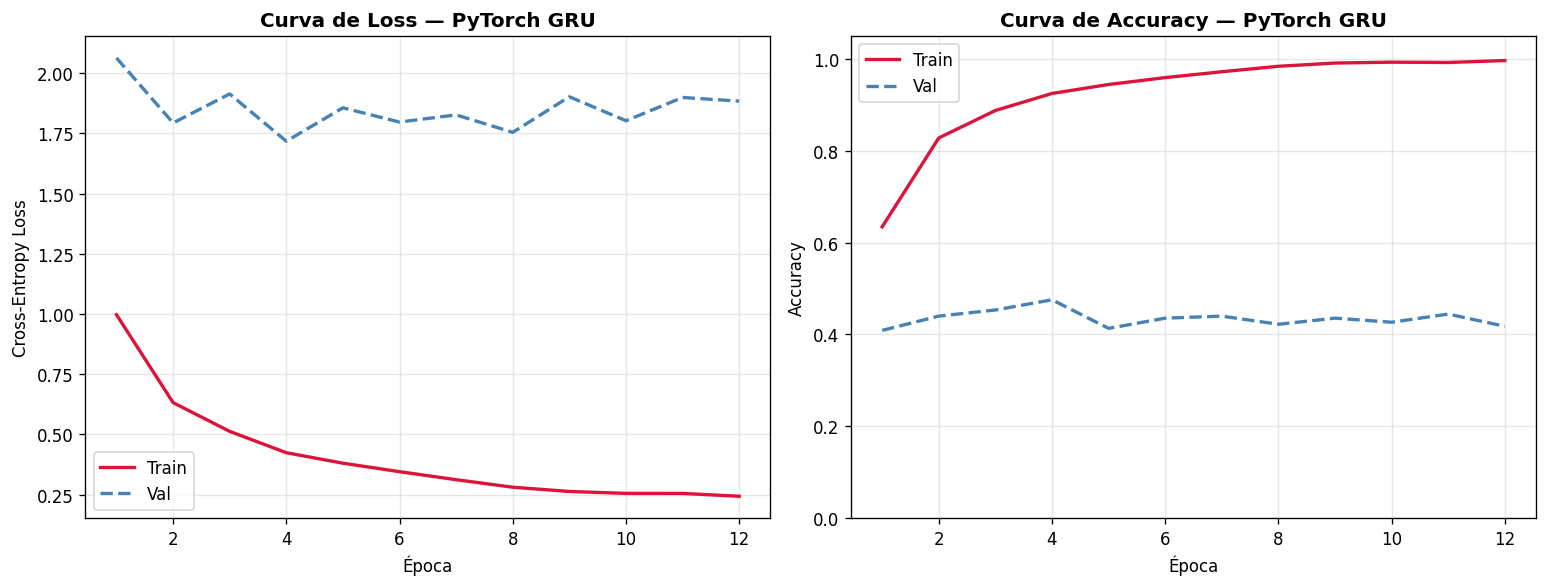

In [29]:
trained_epochs = len(history["train_loss"])
epochs_range = range(1, trained_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(epochs_range, history["train_loss"], label="Train", color="crimson", linewidth=2)
axes[0].plot(epochs_range, history["val_loss"],   label="Val",   color="steelblue", linewidth=2, linestyle="--")
axes[0].set_title("Curva de Loss — PyTorch GRU", fontweight='bold')
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], label="Train", color="crimson", linewidth=2)
axes[1].plot(epochs_range, history["val_acc"],   label="Val",   color="steelblue", linewidth=2, linestyle="--")
axes[1].set_title("Curva de Accuracy — PyTorch GRU", fontweight='bold')
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("plots/pytorch_training_curves.png", bbox_inches='tight')
plt.show()

## 7. Avaliação no Conjunto de Teste

In [ ]:
# Carregar melhor modelo
model.load_state_dict(torch.load("exported_models/modelo_pytorch_gru.pth", map_location=device))
model.eval()

all_preds, all_labels = [], []
test_total_loss = 0.0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        test_total_loss += criterion(out, y).item()
        all_preds.extend(out.argmax(1).cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
test_loss_pt = test_total_loss / len(test_loader)

# Lista de índices de todas as classes
all_class_indices = list(range(len(idx_to_class)))

# Métricas
test_acc_pt = accuracy_score(all_labels, all_preds)
macro_f1_pt = f1_score(all_labels, all_preds, average="macro", labels=all_class_indices, zero_division=0)
weighted_f1_pt = f1_score(all_labels, all_preds, average="weighted", labels=all_class_indices, zero_division=0)
macro_precision_pt = precision_score(all_labels, all_preds, average="macro", labels=all_class_indices, zero_division=0)
macro_recall_pt = recall_score(all_labels, all_preds, average="macro", labels=all_class_indices, zero_division=0)
bal_acc_pt = balanced_accuracy_score(all_labels, all_preds)

print("=" * 55)
print("       AVALIAÇÃO NO CONJUNTO DE TESTE - PyTorch GRU")
print("=" * 55)
print(f"  Test Loss              : {test_loss_pt:.4f}")
print(f"  Test Accuracy          : {test_acc_pt:.4f}")
print(f"  Balanced Accuracy      : {bal_acc_pt:.4f}")
print(f"  Macro F1-Score         : {macro_f1_pt:.4f}")
print(f"  Weighted F1-Score      : {weighted_f1_pt:.4f}")
print(f"  Macro Precision        : {macro_precision_pt:.4f}")
print(f"  Macro Recall           : {macro_recall_pt:.4f}")
print("=" * 55)

print("\nRelatório por Classe:")
print(classification_report(
    all_labels, all_preds,
    labels=all_class_indices,
    target_names=idx_to_class,
    zero_division=0
))

       AVALIAÇÃO NO CONJUNTO DE TESTE - PyTorch GRU
  Test Loss              : 0.6483
  Test Accuracy          : 0.8277
  Balanced Accuracy      : 0.8277
  Macro F1-Score         : 0.8277
  Weighted F1-Score      : 0.8277
  Macro Precision        : 0.8297
  Macro Recall           : 0.8277

Relatório por Classe:
              precision    recall  f1-score   support

       Human       0.90      0.86      0.88       795
      Google       0.80      0.81      0.80       795
        Meta       0.80      0.74      0.77       795
      OpenAI       0.87      0.85      0.86       795
   Anthropic       0.77      0.87      0.82       795

    accuracy                           0.83      3975
   macro avg       0.83      0.83      0.83      3975
weighted avg       0.83      0.83      0.83      3975



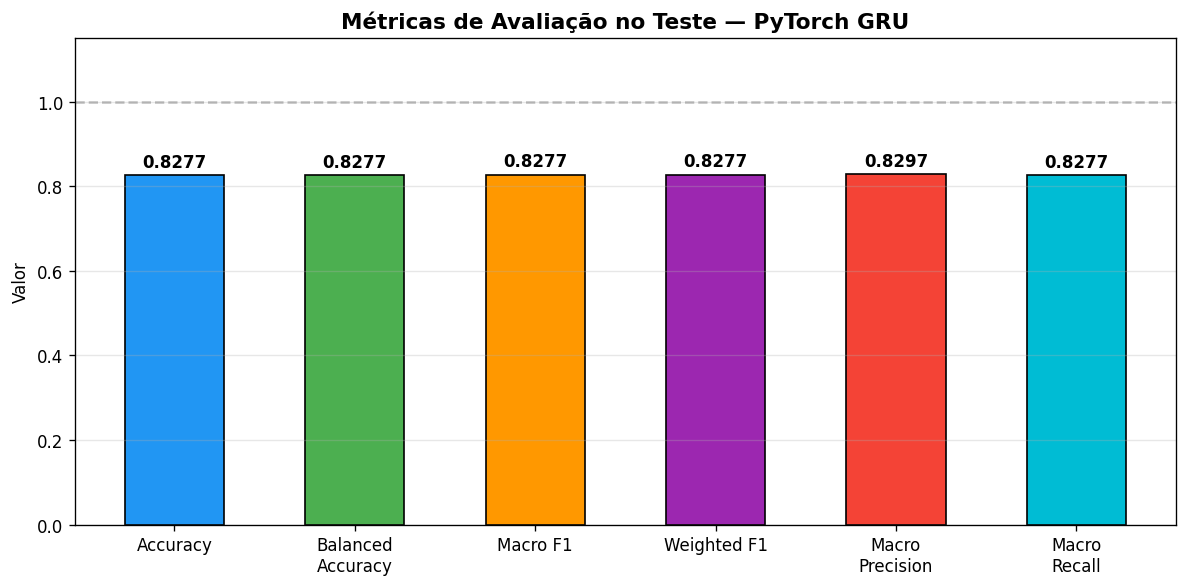

In [31]:
# Gráfico de barras das métricas
metrics_names  = ["Accuracy", "Balanced\nAccuracy", "Macro F1", "Weighted F1", "Macro\nPrecision", "Macro\nRecall"]
metrics_values = [test_acc_pt, bal_acc_pt, macro_f1_pt, weighted_f1_pt, macro_precision_pt, macro_recall_pt]
colors = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='black', width=0.55)
for bar, val in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontweight='bold', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_title("Métricas de Avaliação no Teste — PyTorch GRU", fontsize=13, fontweight='bold')
ax.set_ylabel("Valor")
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pytorch_test_metrics.png", bbox_inches='tight')
plt.show()

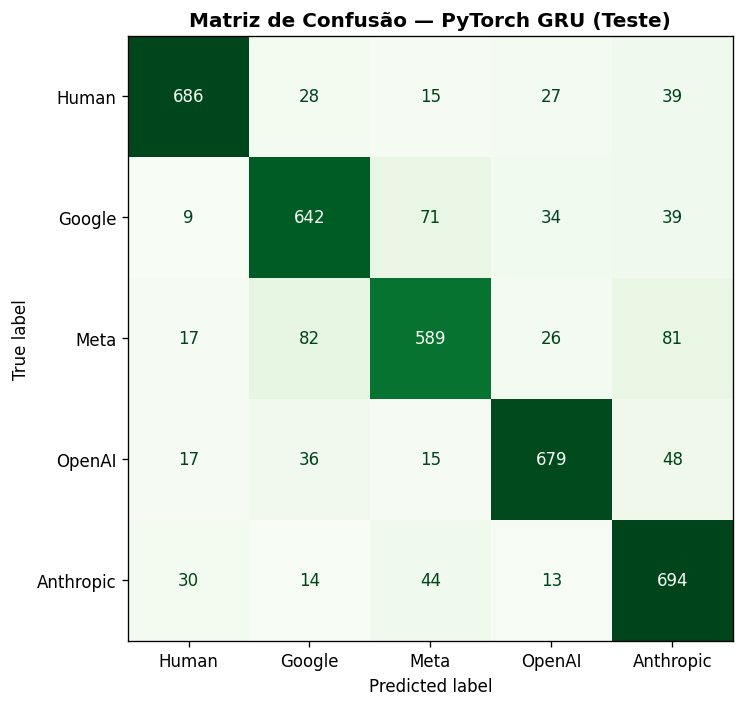

In [32]:
# Matriz de Confusão
cm_pt = confusion_matrix(all_labels, all_preds, labels=all_class_indices)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_pt, display_labels=idx_to_class)
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title("Matriz de Confusão — PyTorch GRU (Teste)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig("plots/pytorch_confusion_matrix.png", bbox_inches='tight')
plt.show()

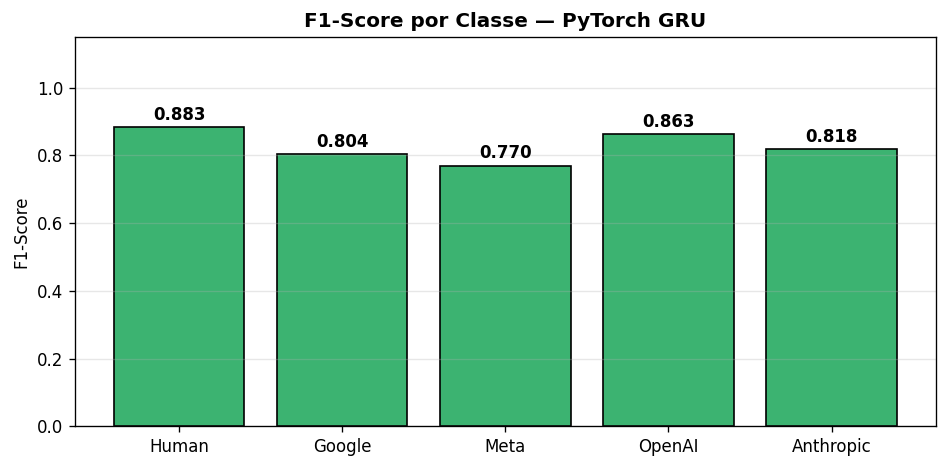


Resumo Final — PyTorch GRU:
  Macro F1   : 0.8277
  Accuracy   : 0.8277
  Bal. Acc   : 0.8277


In [ ]:
# F1-Score por classe
f1_per_class_pt = f1_score(all_labels, all_preds, average=None, labels=all_class_indices, zero_division=0)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(idx_to_class, f1_per_class_pt, color='mediumseagreen', edgecolor='black')
for bar, val in zip(bars, f1_per_class_pt):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.3f}", ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_title("F1-Score por Classe — PyTorch GRU", fontsize=12, fontweight='bold')
ax.set_ylabel("F1-Score")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("plots/pytorch_f1_per_class.png", bbox_inches='tight')
plt.show()

# Guardar métricas PyTorch
pytorch_metrics = {
    "test_loss": test_loss_pt,
    "test_accuracy": test_acc_pt,
    "balanced_accuracy": bal_acc_pt,
    "macro_f1": macro_f1_pt,
    "weighted_f1": weighted_f1_pt,
    "macro_precision": macro_precision_pt,
    "macro_recall": macro_recall_pt,
    "history": history,
    "classes": list(idx_to_class),
    "vocab_size": len(vocab)
}
with open("exported_models/pytorch_metrics.pkl", "wb") as f:
    pickle.dump(pytorch_metrics, f)

print(f"\nResumo Final — PyTorch GRU:")
print(f"  Macro F1   : {macro_f1_pt:.4f}")
print(f"  Accuracy   : {test_acc_pt:.4f}")
print(f"  Bal. Acc   : {bal_acc_pt:.4f}")